In [ ]:
# Read directory.msgpack

import msgpack

directory_path = "../data/azoflip_data/MSGpack/directory.msgpack"
with open(directory_path, "rb") as directory_file:
    dic = next(msgpack.Unpacker(directory_file, strict_map_key=False))


In [2]:
# Find all the msgpacks that contain unsubstituted azobenzene

azobenzene_inchikeys = {
    "Z": "DMLAVOWQYNRWNQ-YPKPFQOONA-N",
    "E": "DMLAVOWQYNRWNQ-BUHFOSPRNA-N",
}
target_inchikeys = set(azobenzene_inchikeys.values())

azobenzene_msgpacks = {}
isomer_counts = {isomer: 0 for isomer in azobenzene_inchikeys}

no_azobenzene_msgpacks = []
for msgpack_name, geometries in dic.items():
    geometry_ids = []
    for geometry_id, geometry in geometries.items():
        inchikey = geometry["species"]["inchikey"]
        if inchikey in target_inchikeys:
            geometry_ids.append(geometry_id)
            isomer = next(
                label for label, key in azobenzene_inchikeys.items() if key == inchikey
            )
            isomer_counts[isomer] += 1
    if geometry_ids:
        azobenzene_msgpacks[msgpack_name] = geometry_ids
    else:
        no_azobenzene_msgpacks.append(msgpack_name)

assert all(
    dic[msgpack_name][geometry_id]["species"]["inchikey"] in target_inchikeys
    for msgpack_name, geometry_ids in azobenzene_msgpacks.items()
    for geometry_id in geometry_ids
)

total_geometries = sum(map(len, azobenzene_msgpacks.values()))
assert total_geometries == 91_321
assert isomer_counts == {"Z": 20_376, "E": 70_945}

print(f"MessagePack files containing azobenzene geometries: {len(azobenzene_msgpacks)}")
print(f"Total geometries: {total_geometries:,}")
print(f"Z: {isomer_counts['Z']:,}; E: {isomer_counts['E']:,}")
for msgpack_name, geometry_ids in sorted(azobenzene_msgpacks.items()):
    print(f"{msgpack_name}: {len(geometry_ids):,}")
print(f"MessagePack files without azobenzene geometries: {len(no_azobenzene_msgpacks)}")


MessagePack files containing azobenzene geometries: 962
Total geometries: 91,321
Z: 20,376; E: 70,945
0000.msgpack: 657
0001.msgpack: 500
0002.msgpack: 501
0003.msgpack: 500
0004.msgpack: 500
0005.msgpack: 501
0006.msgpack: 501
0007.msgpack: 500
0008.msgpack: 500
0009.msgpack: 501
0010.msgpack: 500
0011.msgpack: 266
0012.msgpack: 426
0013.msgpack: 486
0014.msgpack: 499
0016.msgpack: 8
0017.msgpack: 496
0018.msgpack: 500
0019.msgpack: 501
0020.msgpack: 159
0021.msgpack: 243
0022.msgpack: 50
0023.msgpack: 449
0024.msgpack: 221
0025.msgpack: 68
0026.msgpack: 303
0027.msgpack: 297
0028.msgpack: 12
0029.msgpack: 296
0030.msgpack: 253
0031.msgpack: 191
0032.msgpack: 148
0033.msgpack: 281
0034.msgpack: 119
0035.msgpack: 223
0036.msgpack: 158
0037.msgpack: 169
0038.msgpack: 350
0048.msgpack: 1
0049.msgpack: 2
0050.msgpack: 2
0051.msgpack: 8
0052.msgpack: 26
0053.msgpack: 33
0054.msgpack: 3
0055.msgpack: 41
0056.msgpack: 2
0057.msgpack: 3
0058.msgpack: 35
0059.msgpack: 5
0060.msgpack: 7
0061.ms

In [5]:
# Read one msgpack sub-directory

import msgpack

path = '../data/azoflip_data/MSGpack/1367.msgpack'
with open(path, "rb") as msgpack_file:
    directory = next(msgpack.Unpacker(msgpack_file, strict_map_key=False))

print(f"This sub-dictionary has length {len(directory)}")


This sub-dictionary has length 537


Analysed 723 transitions from 537 geometries.
Skipped 0 transitions with incomplete or invalid data.
S0 -> S1: n=537, median energy=1.586 eV, median oscillator strength=0.01209
S0 -> S2: n=93, median energy=3.021 eV, median oscillator strength=0.04975
S0 -> S3: n=93, median energy=3.477 eV, median oscillator strength=0.01063


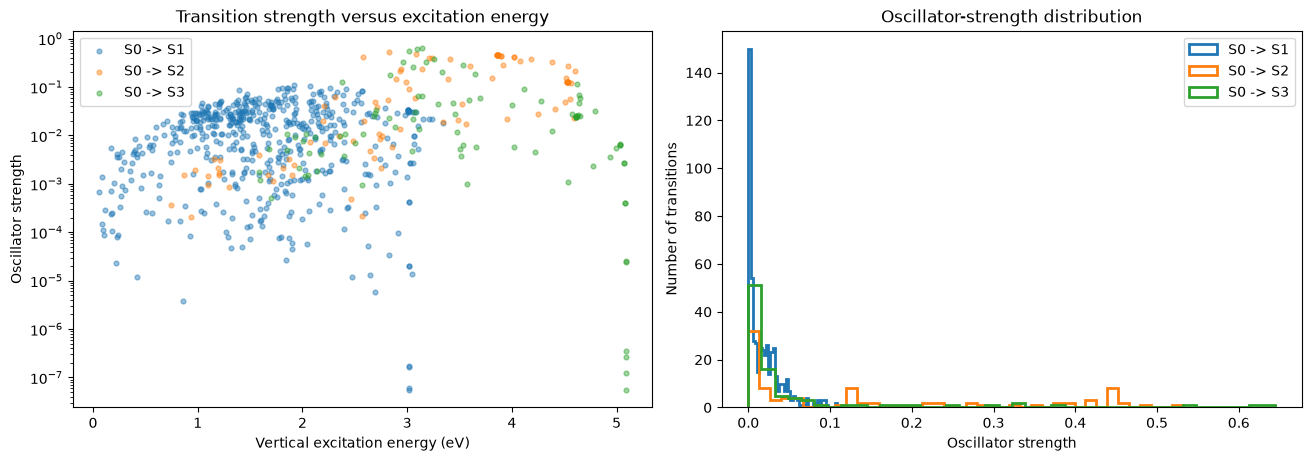

In [6]:
# Analyse ground-state-to-singlet oscillator strengths in the loaded MessagePack.
# The README defines oscillator_strength as a dictionary keyed by absolute state;
# excitedstates identifies the singlets selected by the dataset authors.

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np

HARTREE_TO_EV = 27.211386245988
records = []
skipped_transitions = 0

for geometry_id, geometry in directory.items():
    props = geometry["props"]
    ground_energy = props.get("totalenergy")
    oscillator_strength = props.get("oscillator_strength", {})

    for singlet_number, state in enumerate(props.get("excitedstates", []), start=1):
        absolute_state = state.get("absolutestate")
        strength = oscillator_strength.get(str(absolute_state))
        excited_energy = state.get("energy")
        if None in (ground_energy, absolute_state, strength, excited_energy):
            skipped_transitions += 1
            continue

        excitation_energy = (excited_energy - ground_energy) * HARTREE_TO_EV
        if excitation_energy <= 0 or strength < 0:
            skipped_transitions += 1
            continue
        records.append((geometry_id, singlet_number, excitation_energy, strength))

if not records:
    raise ValueError("No complete ground-state-to-singlet oscillator strengths were found.")

records = np.asarray(records, dtype=float)
by_singlet = defaultdict(list)
for _, singlet_number, excitation_energy, strength in records:
    by_singlet[int(singlet_number)].append((excitation_energy, strength))

print(f"Analysed {len(records):,} transitions from {len(directory):,} geometries.")
print(f"Skipped {skipped_transitions:,} transitions with incomplete or invalid data.")
for singlet_number, values in sorted(by_singlet.items()):
    values = np.asarray(values)
    print(
        f"S0 -> S{singlet_number}: n={len(values):,}, "
        f"median energy={np.median(values[:, 0]):.3f} eV, "
        f"median oscillator strength={np.median(values[:, 1]):.4g}"
    )

fig, (ax_scatter, ax_hist) = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
for singlet_number, values in sorted(by_singlet.items()):
    values = np.asarray(values)
    label = f"S0 -> S{singlet_number}"
    ax_scatter.scatter(values[:, 0], np.maximum(values[:, 1], 1e-8), s=12, alpha=0.45, label=label)
    ax_hist.hist(values[:, 1], bins=40, histtype="step", linewidth=2, label=label)

ax_scatter.set(
    xlabel="Vertical excitation energy (eV)",
    ylabel="Oscillator strength",
    title="Transition strength versus excitation energy",
)
ax_scatter.set_yscale("log")
ax_scatter.legend()
ax_hist.set(
    xlabel="Oscillator strength",
    ylabel="Number of transitions",
    title="Oscillator-strength distribution",
)
ax_hist.legend()
plt.show()


In [7]:
# Write S0 -> S1 oscillator strengths as a single REF_energy target per frame.
# Train X-MACE with n_energies=1 and forces_weight=0.0 for this property-only dataset.

from pathlib import Path
import json

atomic_symbols = {1: "H", 6: "C", 7: "N"}
output_path = Path("../data/azoflip_data/XYZ/1367_s0_s1_oscillator_strength.xyz")
skipped_geometry_ids = []
written_geometries = 0

with output_path.open("w") as xyz_file:
    for geometry_id, geometry in directory.items():
        props = geometry["props"]
        excited_states = props.get("excitedstates", [])
        first_excited_state = excited_states[0] if excited_states else {}
        first_excited_absolute_state = first_excited_state.get("absolutestate")
        oscillator_strength = props.get("oscillator_strength", {}).get(
            str(first_excited_absolute_state)
        )

        if oscillator_strength is None or oscillator_strength < 0:
            skipped_geometry_ids.append(geometry_id)
            continue

        coordinates = geometry["xyz"]
        xyz_file.write(f"{len(coordinates)}\n")
        xyz_file.write(
            "Properties=species:S:1:pos:R:3 "
            f'REF_energy="_JSON {json.dumps([[float(oscillator_strength)]])}" '
            f"geometry_id={geometry_id}\n"
        )
        for atomic_number, x, y, z in coordinates:
            xyz_file.write(f"{atomic_symbols[int(atomic_number)]:<2} {x: .8f} {y: .8f} {z: .8f}\n")
        written_geometries += 1

print(f"Wrote {written_geometries:,} S0 -> S1 oscillator strengths to {output_path}")
print(f"Skipped {len(skipped_geometry_ids):,} geometries without an S0 -> S1 oscillator strength")


Wrote 537 S0 -> S1 oscillator strengths to ../data/azoflip_data/XYZ/1367_s0_s1_oscillator_strength.xyz
Skipped 0 geometries without an S0 -> S1 oscillator strength


In [4]:
# Write XYZ file with energies and forces

import json

atomic_symbols = {1: "H", 6: "C", 7: "N"}
output_path = "../data/azoflip_data/XYZ/1367_ground_first_excited.xyz"
skipped_geometry_ids = []

with open(output_path, "w") as xyz_file:
    for geometry_id, geometry in directory.items():
        coordinates = geometry["xyz"]
        ground_energy = geometry["props"].get("totalenergy")
        ground_forces = geometry["props"].get("forces")
        excited_states = geometry["props"].get("excitedstates", [])
        first_excited_state = excited_states[0] if excited_states else {}
        first_excited_energy = first_excited_state.get("energy")
        first_excited_forces = first_excited_state.get("forces")

        energies = [[ground_energy, first_excited_energy]]
        forces = [ground_forces, first_excited_forces]

        if (
            any(energy is None for energy in energies[0])
            or any(force is None or len(force) != len(coordinates) for force in forces)
        ):
            skipped_geometry_ids.append(geometry_id)
            continue

        # X-MACE expects forces as [atom, state, Cartesian component].
        forces_by_atom = [
            [ground_force, excited_force]
            for ground_force, excited_force in zip(ground_forces, first_excited_forces)
        ]

        xyz_file.write(f"{len(coordinates)}\n")
        xyz_file.write(
            "Properties=species:S:1:pos:R:3 "
            f'REF_energy="_JSON {json.dumps(energies)}" '
            f'REF_forces="_JSON {json.dumps(forces_by_atom)}"\n'
        )
        for atomic_number, x, y, z in coordinates:
            symbol = atomic_symbols[int(atomic_number)]
            xyz_file.write(f"{symbol:<2} {x: .8f} {y: .8f} {z: .8f}\n")

written_geometries = len(directory) - len(skipped_geometry_ids)
print(f"Wrote {written_geometries} geometries to {output_path}")
print(f"Skipped {len(skipped_geometry_ids)} geometries without complete energy/force data")
if skipped_geometry_ids:
    print(f"Skipped geometry IDs: {skipped_geometry_ids}")


Wrote 461 geometries to ../data/azoflip_data/XYZ/1367_ground_first_excited.xyz
Skipped 76 geometries without complete energy/force data
Skipped geometry IDs: [83069875, 56321748, 56354967, 56760963, 56796844, 56785808, 56838834, 58512212, 57000185, 83674453, 81662905, 81662897, 83054009, 55202629, 55295245, 53588863, 53588865, 53588866, 53588867, 53590516, 53590517, 58292036, 58292037, 58292038, 58292039, 53590518, 53590519, 53590523, 53590525, 58292025, 58292026, 58292027, 58292032, 58292033, 58292034, 55263815, 56354962, 56761449, 56999939, 57114828, 56992010, 84490877, 56391599, 56404985, 56794948, 84490959, 56809207, 55433831, 55449126, 55509833, 55510444, 55775496, 56069544, 58292029, 56373711, 56193092, 56354619, 56322376, 56330491, 56998201, 54147706, 58292024, 56760873, 53588868, 53590521, 55401235, 56321755, 53588864, 53590520, 58292028, 58292030, 58292031, 58292035, 53590522, 53590524, 53590526]


In [ ]:
# Generate an azobenzene CNNC torsion / N--N distance grid.
# `directory` must be loaded first (for example, by the preceding MessagePack cell).

from collections import deque
from pathlib import Path

import numpy as np

# Both endpoints are included.
cnnc_dihedrals_deg = np.arange(0.0, 180.0 + 0.5, 5.0)
nn_distances_angstrom = np.linspace(1.0, 1.6, 31)  # 0.02 Angstrom spacing
output_path = Path("../data/azoflip_data/XYZ/azobenzene_cnnd_nn_grid.xyz")

E_INCHIKEY = "DMLAVOWQYNRWNQ-BUHFOSPRNA-N"
reference = next(
    geometry
    for geometry in directory.values()
    if geometry["species"]["inchikey"] == E_INCHIKEY
)
atomic_numbers = np.asarray([int(atom[0]) for atom in reference["xyz"]])
reference_positions = np.asarray([atom[1:] for atom in reference["xyz"]], dtype=float)
symbols = {1: "H", 6: "C", 7: "N"}

# Infer the molecular graph from the reference geometry, then split it at N=N.
covalent_radii = {1: 0.31, 6: 0.76, 7: 0.71}
adjacency = [set() for _ in atomic_numbers]
for i in range(len(atomic_numbers)):
    for j in range(i):
        cutoff = 1.25 * (covalent_radii[atomic_numbers[i]] + covalent_radii[atomic_numbers[j]])
        if np.linalg.norm(reference_positions[i] - reference_positions[j]) < cutoff:
            adjacency[i].add(j)
            adjacency[j].add(i)

nitrogen_indices = np.flatnonzero(atomic_numbers == 7).tolist()
if len(nitrogen_indices) != 2:
    raise ValueError(f"Expected two nitrogens, found {nitrogen_indices}")
n1, n2 = nitrogen_indices
if n2 not in adjacency[n1]:
    raise ValueError("Could not identify the N=N bond in the reference geometry.")

adjacency[n1].remove(n2)
adjacency[n2].remove(n1)
fragment_2 = set([n2])
queue = deque([n2])
while queue:
    atom = queue.popleft()
    for neighbour in adjacency[atom]:
        if neighbour not in fragment_2:
            fragment_2.add(neighbour)
            queue.append(neighbour)
if len(fragment_2) * 2 != len(atomic_numbers):
    raise ValueError("Splitting at N=N did not produce two phenyl-N fragments.")
fragment_2 = np.asarray(sorted(fragment_2))

def attached_carbon(nitrogen, other_nitrogen):
    carbons = [atom for atom in adjacency[nitrogen] if atomic_numbers[atom] == 6]
    if len(carbons) != 1:
        raise ValueError(f"Expected one carbon attached to N index {nitrogen}; found {carbons}")
    return carbons[0]

c1 = attached_carbon(n1, n2)
c2 = attached_carbon(n2, n1)

def dihedral_degrees(points, indices):
    p0, p1, p2, p3 = points[list(indices)]
    b0, b1, b2 = p1 - p0, p2 - p1, p3 - p2
    axis = b1 / np.linalg.norm(b1)
    v = b0 - np.dot(b0, axis) * axis
    w = b2 - np.dot(b2, axis) * axis
    return np.degrees(np.arctan2(np.dot(np.cross(axis, v), w), np.dot(v, w)))

def rotate_about_axis(points, atom_indices, origin, axis, angle_degrees):
    axis = axis / np.linalg.norm(axis)
    angle = np.radians(angle_degrees)
    vectors = points[atom_indices] - origin
    rotated = (
        vectors * np.cos(angle)
        + np.cross(axis, vectors) * np.sin(angle)
        + np.outer(vectors @ axis, axis) * (1.0 - np.cos(angle))
    )
    points[atom_indices] = rotated + origin

def angular_error(actual, expected):
    return (actual - expected + 180.0) % 360.0 - 180.0

def constrained_geometry(nn_distance, cnnc_dihedral):
    positions = reference_positions.copy()
    axis = positions[n2] - positions[n1]
    positions[fragment_2] += (nn_distance - np.linalg.norm(axis)) * axis / np.linalg.norm(axis)
    current = dihedral_degrees(positions, (c1, n1, n2, c2))
    rotation = cnnc_dihedral - current

    # Select the rotation sign that matches this dihedral convention.
    candidates = []
    for sign in (1.0, -1.0):
        candidate = positions.copy()
        rotate_about_axis(candidate, fragment_2, candidate[n2], candidate[n2] - candidate[n1], sign * rotation)
        error = abs(angular_error(dihedral_degrees(candidate, (c1, n1, n2, c2)), cnnc_dihedral))
        candidates.append((error, candidate))
    positions = min(candidates, key=lambda item: item[0])[1]

    measured_distance = np.linalg.norm(positions[n2] - positions[n1])
    measured_dihedral = dihedral_degrees(positions, (c1, n1, n2, c2))
    assert np.isclose(measured_distance, nn_distance, atol=1e-10)
    assert abs(angular_error(measured_dihedral, cnnc_dihedral)) < 1e-8
    return positions

output_path.parent.mkdir(parents=True, exist_ok=True)
with output_path.open("w") as xyz_file:
    for nn_distance in nn_distances_angstrom:
        for cnnc_dihedral in cnnc_dihedrals_deg:
            positions = constrained_geometry(nn_distance, cnnc_dihedral)
            xyz_file.write(f"{len(atomic_numbers)}\n")
            xyz_file.write(f"cnnc_dihedral_deg={cnnc_dihedral:.8f} nn_distance_angstrom={nn_distance:.8f} reference_geometry_id={reference['id']}\n")
            for atomic_number, (x, y, z) in zip(atomic_numbers, positions):
                xyz_file.write(f"{symbols[atomic_number]:<2} {x: .8f} {y: .8f} {z: .8f}\n")

print(f"Wrote {len(cnnc_dihedrals_deg) * len(nn_distances_angstrom):,} geometries to {output_path} ({cnnc_dihedrals_deg[0]:g}--{cnnc_dihedrals_deg[-1]:g} degrees; {nn_distances_angstrom[0]:.2f}--{nn_distances_angstrom[-1]:.2f} Angstrom).")


In [ ]:
# Predict state-resolved energies and forces for the CNNC / N--N grid.
# The model was saved with CUDA tensors, so execute this cell on a CUDA-enabled host.

import json
from pathlib import Path

import ase.io
import numpy as np
import torch
from mace.calculators import MACECalculator

grid_path = Path("../data/azoflip_data/XYZ/azobenzene_cnnd_nn_grid.xyz")
model_path = Path("../outputs/base_models/base_model_azoflip.pt")
if not grid_path.is_file():
    raise FileNotFoundError(f"Grid XYZ does not exist: {grid_path}")
if not model_path.is_file():
    raise FileNotFoundError(f"Model does not exist: {model_path}")
if not torch.cuda.is_available():
    raise RuntimeError("base_model_azoflip.pt is CUDA-serialized; run this cell with a CUDA-enabled PyTorch installation.")

device = "cuda"
calculator = MACECalculator(model_paths=model_path, device=device)
calculator.model.eval()
frames = ase.io.read(grid_path, index=":")
if not frames:
    raise ValueError(f"No structures found in {grid_path}")

predictions = []
for frame_index, atoms in enumerate(frames, start=1):
    atoms.calc = calculator
    energies = np.asarray(atoms.get_potential_energy(), dtype=float).reshape(1, -1)
    forces = np.asarray(atoms.get_forces(), dtype=float)
    if forces.shape != (len(atoms), energies.shape[1], 3):
        raise ValueError(
            f"Unexpected force shape for frame {frame_index}: {forces.shape}; "
            f"expected {(len(atoms), energies.shape[1], 3)}"
        )
    predictions.append((energies, forces))
    if frame_index % 100 == 0 or frame_index == len(frames):
        print(f"Predicted {frame_index:,}/{len(frames):,} structures")

# Use a temporary file so the existing grid is retained if prediction fails.
temporary_path = grid_path.with_suffix(grid_path.suffix + ".tmp")
with temporary_path.open("w") as xyz_file:
    for atoms, (energies, forces) in zip(frames, predictions):
        cnnc_dihedral = float(atoms.info["cnnc_dihedral_deg"])
        nn_distance = float(atoms.info["nn_distance_angstrom"])
        reference_id = atoms.info["reference_geometry_id"]
        xyz_file.write(f"{len(atoms)}\n")
        xyz_file.write(
            "Properties=species:S:1:pos:R:3 "
            f'REF_energy="_JSON {json.dumps(energies.tolist())}" ' 
            f'REF_forces="_JSON {json.dumps(forces.tolist())}" ' 
            f"cnnc_dihedral_deg={cnnc_dihedral:.8f} "
            f"nn_distance_angstrom={nn_distance:.8f} "
            f"reference_geometry_id={reference_id}\n"
        )
        for symbol, (x, y, z) in zip(atoms.get_chemical_symbols(), atoms.positions):
            xyz_file.write(f"{symbol:<2} {x: .8f} {y: .8f} {z: .8f}\n")
temporary_path.replace(grid_path)
print(f"Wrote {len(frames):,} predicted structures to {grid_path}")


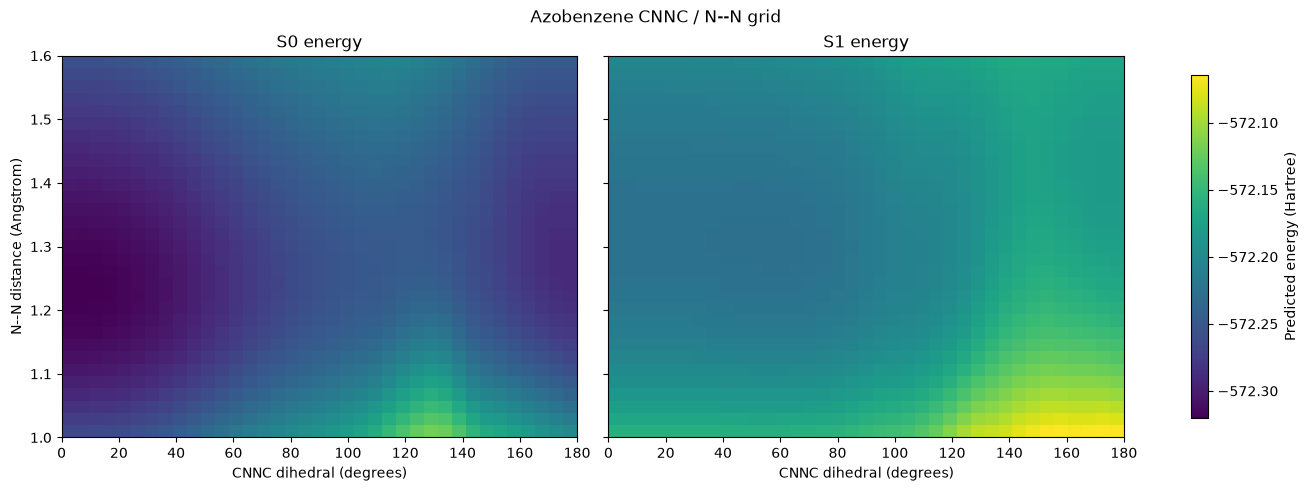

In [5]:
# Plot S0 and S1 energy surfaces from the predicted static azobenzene grid.

from pathlib import Path

import ase.io
import matplotlib.pyplot as plt
import numpy as np

grid_path = Path("../data/azoflip_data/XYZ/azobenzene_rotated_grid_static.xyz")
frames = ase.io.read(grid_path, index=":")
if not frames:
    raise ValueError(f"No structures found in {grid_path}")

dihedrals = np.asarray([frame.info["cnnc_dihedral_deg"] for frame in frames], dtype=float)
nn_distances = np.asarray([frame.info["nn_distance_angstrom"] for frame in frames], dtype=float)
energies = np.vstack([np.asarray(frame.info["REF_energy"], dtype=float).reshape(-1) for frame in frames])
if energies.shape[1] < 2:
    raise ValueError(f"Expected S0 and S1 energies, found shape {energies.shape}")

dihedral_values = np.unique(dihedrals)
nn_distance_values = np.unique(nn_distances)
if len(frames) != len(dihedral_values) * len(nn_distance_values):
    raise ValueError("Grid is incomplete or contains duplicate CNNC/N--N coordinate pairs.")

energy_grid = np.full((2, len(nn_distance_values), len(dihedral_values)), np.nan)
dihedral_index = {value: index for index, value in enumerate(dihedral_values)}
nn_distance_index = {value: index for index, value in enumerate(nn_distance_values)}
for dihedral, nn_distance, state_energies in zip(dihedrals, nn_distances, energies):
    energy_grid[:, nn_distance_index[nn_distance], dihedral_index[dihedral]] = state_energies[:2]
if np.isnan(energy_grid).any():
    raise ValueError("Could not populate every S0/S1 grid point.")

vmin, vmax = energy_grid.min(), energy_grid.max()
if np.isclose(vmin, vmax):
    vmin, vmax = vmin - 0.5, vmax + 0.5

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True, sharey=True, constrained_layout=True)
extent = [dihedral_values[0], dihedral_values[-1], nn_distance_values[0], nn_distance_values[-1]]
for state, axis in enumerate(axes):
    image = axis.imshow(
        energy_grid[state], origin="lower", aspect="auto", extent=extent,
        cmap="viridis", vmin=vmin, vmax=vmax, interpolation="nearest",
    )
    axis.set(title=f"S{state} energy", xlabel="CNNC dihedral (degrees)")
axes[0].set_ylabel("N--N distance (Angstrom)")
colorbar = fig.colorbar(image, ax=axes, shrink=0.9)
colorbar.set_label("Predicted energy (Hartree)")
fig.suptitle("Azobenzene CNNC / N--N grid")
plt.show()


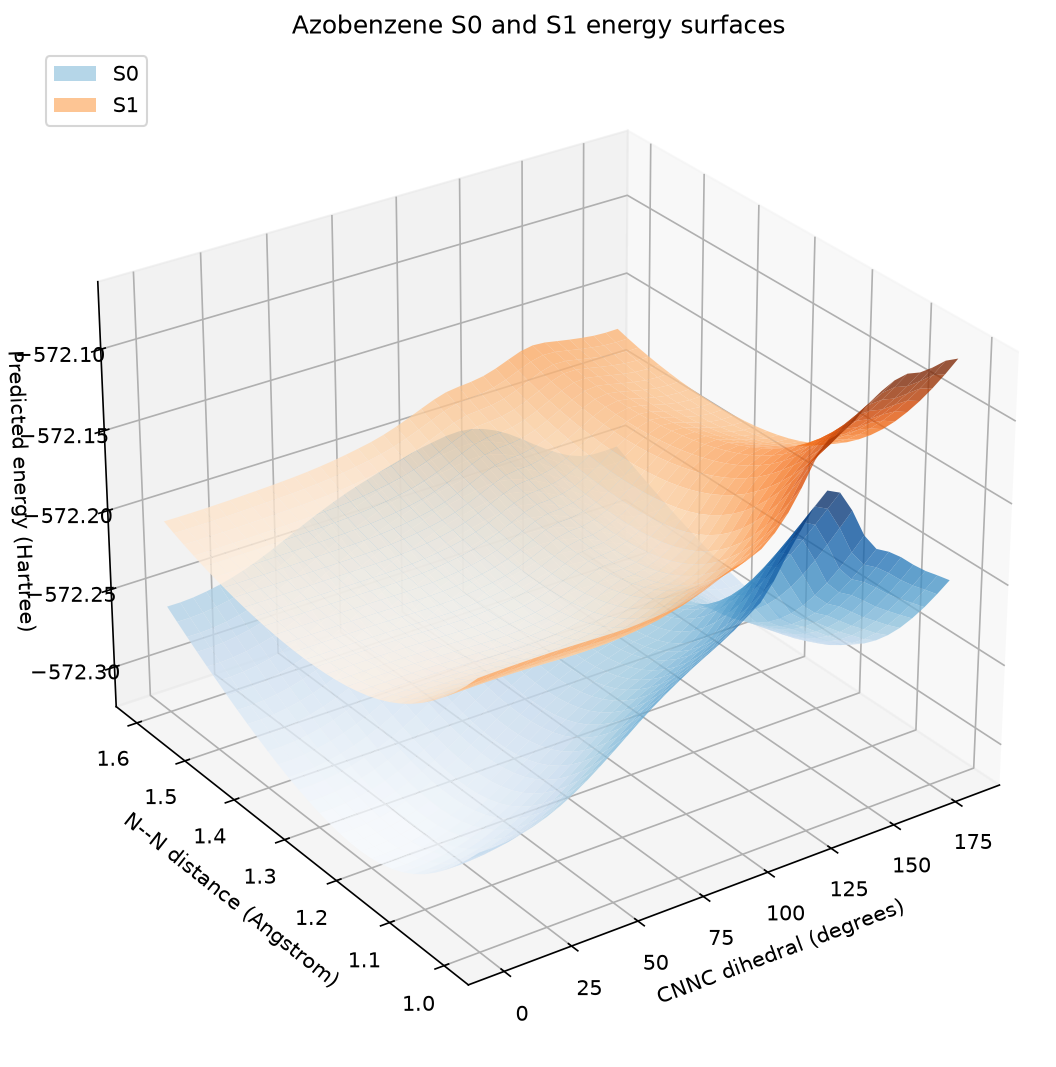

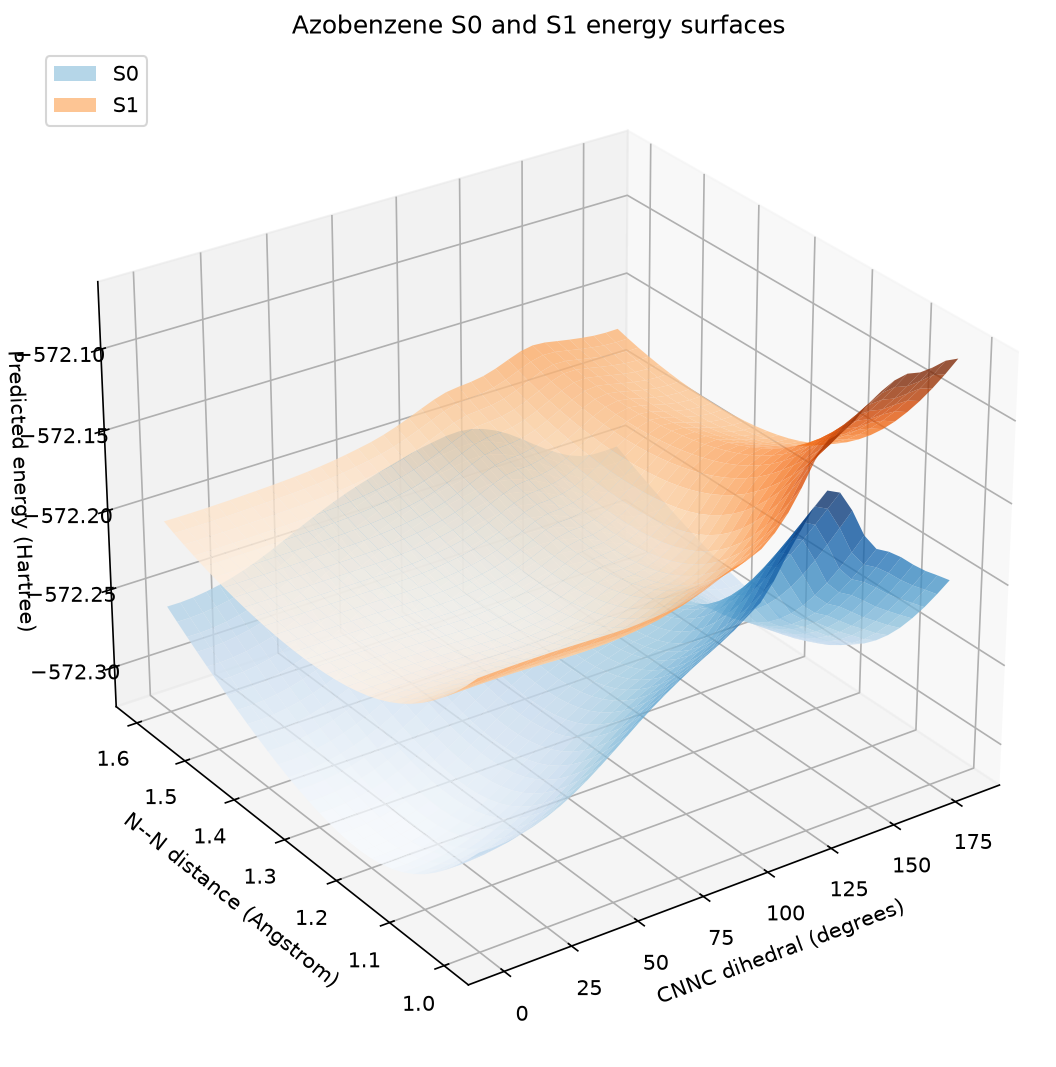

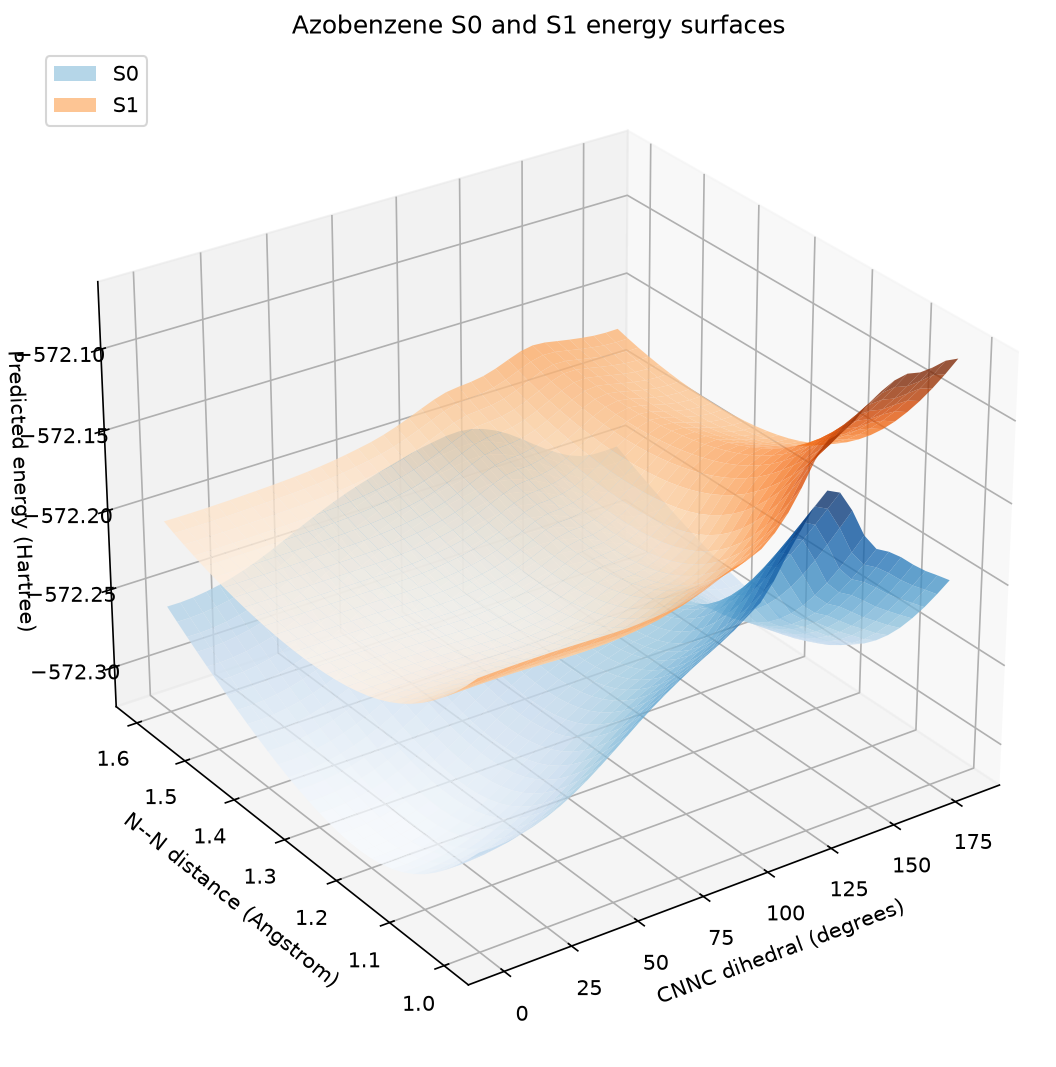

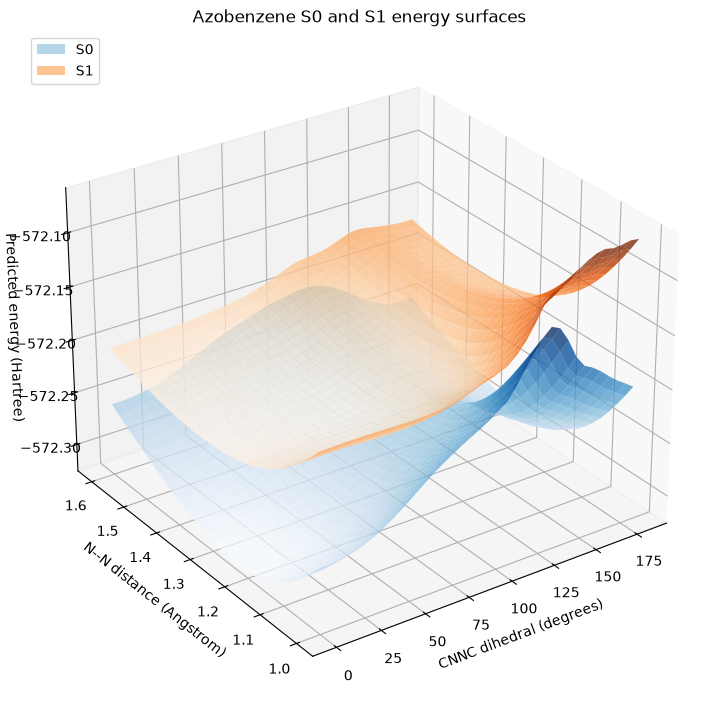

In [10]:
# Plot 3D S0 and S1 energy surfaces for the static azobenzene grid.
%matplotlib inline
from pathlib import Path

import ase.io
import matplotlib.pyplot as plt
import numpy as np

grid_path = Path("../data/azoflip_data/XYZ/azobenzene_rotated_grid_static.xyz")
frames = ase.io.read(grid_path, index=":")
if not frames:
    raise ValueError(f"No structures found in {grid_path}")

dihedrals = np.asarray([frame.info["cnnc_dihedral_deg"] for frame in frames], dtype=float)
nn_distances = np.asarray([frame.info["nn_distance_angstrom"] for frame in frames], dtype=float)
energies = np.vstack([np.asarray(frame.info["REF_energy"], dtype=float).reshape(-1) for frame in frames])
if energies.shape[1] < 2:
    raise ValueError(f"Expected S0 and S1 energies, found shape {energies.shape}")

dihedral_values = np.unique(dihedrals)
nn_distance_values = np.unique(nn_distances)
if len(frames) != len(dihedral_values) * len(nn_distance_values):
    raise ValueError("Grid is incomplete or contains duplicate CNNC/N--N coordinate pairs.")

energy_grid = np.full((2, len(nn_distance_values), len(dihedral_values)), np.nan)
dihedral_index = {value: index for index, value in enumerate(dihedral_values)}
nn_distance_index = {value: index for index, value in enumerate(nn_distance_values)}
for dihedral, nn_distance, state_energies in zip(dihedrals, nn_distances, energies):
    energy_grid[:, nn_distance_index[nn_distance], dihedral_index[dihedral]] = state_energies[:2]
if np.isnan(energy_grid).any():
    raise ValueError("Could not populate every S0/S1 grid point.")

dihedral_mesh, nn_distance_mesh = np.meshgrid(dihedral_values, nn_distance_values)
fig = plt.figure(figsize=(9, 7), constrained_layout=True)
axis = fig.add_subplot(projection="3d")
s0_surface = axis.plot_surface(
    dihedral_mesh, nn_distance_mesh, energy_grid[0], cmap="Blues",
    linewidth=0, antialiased=True, alpha=0.78,
)
s1_surface = axis.plot_surface(
    dihedral_mesh, nn_distance_mesh, energy_grid[1], cmap="Oranges",
    linewidth=0, antialiased=True, alpha=0.78,
)
axis.set(
    title="Azobenzene S0 and S1 energy surfaces",
    xlabel="CNNC dihedral (degrees)",
    ylabel="N--N distance (Angstrom)",
    zlabel="Predicted energy (Hartree)",
)
axis.view_init(elev=28, azim=-125)
axis.legend([s0_surface, s1_surface], ["S0", "S1"], loc="upper left")
plt.show()


In [ ]:
# Generate the same CNNC / N--N grid after rotating one phenyl ring by 90 degrees.
# Run the `generate-cnnd-nn-grid` cell first: this cell reuses its reference and geometry helpers.

import json

ring_rotation_deg = 90.0
rotated_output_path = Path("../data/azoflip_data/XYZ/azobenzene_cnnd_nn_grid_ring_rotated_90.xyz")
ring_2 = fragment_2[fragment_2 != n2]  # Phenyl ring attached to N index n2; N itself remains fixed.
if c2 not in ring_2:
    raise ValueError("The selected phenyl-ring fragment does not contain its N--C attachment atom.")

def constrained_geometry_with_rotated_ring(nn_distance, cnnc_dihedral):
    positions = constrained_geometry(nn_distance, cnnc_dihedral)
    # Rotate the complete phenyl ring about its N--C bond. C2 lies on the axis.
    rotate_about_axis(
        positions, ring_2, positions[n2], positions[c2] - positions[n2], ring_rotation_deg
    )
    assert np.isclose(np.linalg.norm(positions[n2] - positions[n1]), nn_distance, atol=1e-10)
    assert abs(angular_error(dihedral_degrees(positions, (c1, n1, n2, c2)), cnnc_dihedral)) < 1e-8
    return positions

rotated_output_path.parent.mkdir(parents=True, exist_ok=True)
with rotated_output_path.open("w") as xyz_file:
    for nn_distance in nn_distances_angstrom:
        for cnnc_dihedral in cnnc_dihedrals_deg:
            positions = constrained_geometry_with_rotated_ring(nn_distance, cnnc_dihedral)
            xyz_file.write(f"{len(atomic_numbers)}\n")
            xyz_file.write(
                f"cnnc_dihedral_deg={cnnc_dihedral:.8f} nn_distance_angstrom={nn_distance:.8f} "
                f"benzene_ring_rotation_deg={ring_rotation_deg:.8f} reference_geometry_id={reference['id']}\n"
            )
            for atomic_number, (x, y, z) in zip(atomic_numbers, positions):
                xyz_file.write(f"{symbols[atomic_number]:<2} {x: .8f} {y: .8f} {z: .8f}\n")

print(f"Wrote {len(cnnc_dihedrals_deg) * len(nn_distances_angstrom):,} 90-degree ring-rotated geometries to {rotated_output_path}")
